## 0. Import Required Libraries

In [14]:
# import shutil
# source_path = '/kaggle/input/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset/data'
# target_path = '/kaggle/working/data'
# shutil.copytree(source_path, target_path)

In [15]:
# !rm -rf /kaggle/working/data/Samples

In [16]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
import timm

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


## 1. Data Preparation

In [17]:
# Define data paths
DATA_DIR = '/kaggle/working/data'
CLASS_0_DIR = os.path.join(DATA_DIR, 'S1SAR_UnBalanced_400by400_Class_0', '0')
CLASS_1_DIR = os.path.join(DATA_DIR, 'S1SAR_UnBalanced_400by400_Class_1', '1')

# Gather image paths and labels
image_paths = []
labels = []

for img_name in os.listdir(CLASS_0_DIR):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        image_paths.append(os.path.join(CLASS_0_DIR, img_name))
        labels.append(0)

for img_name in os.listdir(CLASS_1_DIR):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        image_paths.append(os.path.join(CLASS_1_DIR, img_name))
        labels.append(1)

print(f"Total images: {len(image_paths)}")
print(f"Class 0 (no oil): {labels.count(0)}")
print(f"Class 1 (oil spill): {labels.count(1)}")

# Train/val/test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42  # 0.25 * 0.8 = 0.2 of total
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Compute class weights for imbalance handling
class_counts = [y_train.count(0), y_train.count(1)]
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
print(f"Class weights: {class_weights.tolist()}")

Total images: 5630
Class 0 (no oil): 3725
Class 1 (oil spill): 1905
Train: 3378 | Val: 1126 | Test: 1126
Class weights: [0.3383658826351166, 0.661634087562561]


## 2. Dataset and Transforms

In [18]:
class SAROilDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L')  # convert to grayscale
        image = image.convert('RGB')  # 3-channel for pretrained models
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Transforms for training (with augmentation) and validation/test
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SAROilDataset(X_train, y_train, transform=train_transform)
val_dataset = SAROilDataset(X_val, y_val, transform=val_transform)
test_dataset = SAROilDataset(X_test, y_test, transform=val_transform)

# Create weighted sampler to handle imbalance
sample_weights = [class_weights[y] for y in y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


## 3. Model Building and Training Functions

In [19]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_weights = {
    "resnet50": "/kaggle/input/datasets/qihuiren/resnet50-timm/resnet50_timm.pth",
    "efficientnet_b0": "/kaggle/input/datasets/qihuiren/efficientnet-b0/efficientnet_b0_timm.pth",
    "mobilenetv3_large_100": "/kaggle/input/datasets/qihuiren/mnv3-large/mobilenetv3_large_100_timm.pth",
}

def build_model(model_name, num_classes=2, pretrained=False, weights_path=None):
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    if weights_path is not None:
        state_dict = torch.load(weights_path, map_location="cpu")
        model_state = model.state_dict()
        filtered_state = {k: v for k, v in state_dict.items() 
                          if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered_state)
        model.load_state_dict(model_state)
        print(f"Loaded local weights from {weights_path}")
    return model.to(device)

def train_model(model, train_loader, val_loader, epochs, lr, loss_fn, patience=5, model_save_name='best_model.pth'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1 = 0.0
    wait = 0
    train_losses = []
    val_f1s = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                preds = logits.argmax(1)
                y_true.extend(y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        val_f1 = f1_score(y_true, y_pred)
        val_f1s.append(val_f1)
        print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_f1={val_f1:.4f}")

        # Early stopping & save best
        if val_f1 > best_f1:
            best_f1 = val_f1
            wait = 0
            torch.save(model.state_dict(), model_save_name)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    print(f"Best validation F1: {best_f1:.4f}")
    return model, train_losses, val_f1s

# Focal Loss (for imbalanced data)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=1.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Weighted CrossEntropy (using class weights)
ce_loss = nn.CrossEntropyLoss(weight=class_weights.to(device))

Using device: cuda


## 4. Train Individual Models

In [20]:
# ResNet50
print("\n--- Training ResNet50 ---")
model_resnet = build_model("resnet50", num_classes=2, pretrained=False, weights_path=model_weights["resnet50"])
model_resnet, _, _ = train_model(
    model_resnet, train_loader, val_loader, epochs=20, lr=1e-3,
    loss_fn=ce_loss, model_save_name="best_resnet50.pth"
)

# EfficientNet-B0
print("\n--- Training EfficientNet-B0 ---")
model_eff = build_model("efficientnet_b0", num_classes=2, pretrained=False, weights_path=model_weights["efficientnet_b0"])
focal_loss = FocalLoss(gamma=2.0)
model_eff, _, _ = train_model(
    model_eff, train_loader, val_loader, epochs=20, lr=5e-4,
    loss_fn=focal_loss, model_save_name="best_efficientnet.pth"
)

# MobileNetV3-Large
print("\n--- Training MobileNetV3-Large ---")
model_mob_large = build_model("mobilenetv3_large_100", num_classes=2, pretrained=False, weights_path=model_weights["mobilenetv3_large_100"])
model_mob_large, _, _ = train_model(
    model_mob_large, train_loader, val_loader, epochs=20, lr=2e-3,
    loss_fn=ce_loss, model_save_name="best_mobilenet_large.pth"
)


--- Training ResNet50 ---
Loaded local weights from /kaggle/input/datasets/qihuiren/resnet50-timm/resnet50_timm.pth


Epoch 1/20: 100%|██████████| 106/106 [00:40<00:00,  2.59it/s]


Epoch 1: train_loss=0.3407, val_f1=0.8439


Epoch 2/20: 100%|██████████| 106/106 [00:42<00:00,  2.52it/s]


Epoch 2: train_loss=0.1705, val_f1=0.9237


...

Epoch 8: train_loss=0.1631, val_f1=0.8889


Epoch 9/20: 100%|██████████| 106/106 [00:11<00:00,  8.96it/s]


Epoch 9: train_loss=0.1500, val_f1=0.8677


Epoch 10/20: 100%|██████████| 106/106 [00:11<00:00,  9.11it/s]


Epoch 10: train_loss=0.1341, val_f1=0.8549
Early stopping triggered.
Best validation F1: 0.9217


## 5. Uncertainty-Weighted Ensemble

In [22]:
model_resnet.load_state_dict(torch.load("best_resnet50.pth", map_location=device))
model_eff.load_state_dict(torch.load("best_efficientnet.pth", map_location=device))
model_mob_large.load_state_dict(torch.load("best_mobilenet_large.pth", map_location=device))
models = [model_resnet, model_eff, model_mob_large]

def entropy(p):
    return -torch.sum(p * torch.log(p + 1e-8), dim=1)

def ensemble_predict(models, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Ensemble inference"):
            x, y = x.to(device), y.to(device)
            probs = []
            entropies = []
            for m in models:
                m.eval()
                p = F.softmax(m(x), dim=1)
                probs.append(p)
                entropies.append(entropy(p))
            probs = torch.stack(probs)          # [num_models, batch, 2]
            entropies = torch.stack(entropies)  # [num_models, batch]
            weights = 1 - entropies / np.log(2)
            weights = weights.unsqueeze(-1)
            weighted_avg = torch.sum(probs * weights, dim=0) / torch.sum(weights, dim=0)
            preds = weighted_avg.argmax(1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

y_true_ens, y_pred_ens = ensemble_predict(models, test_loader)
acc_ens = accuracy_score(y_true_ens, y_pred_ens)
prec_ens = precision_score(y_true_ens, y_pred_ens)
rec_ens = recall_score(y_true_ens, y_pred_ens)
f1_ens = f1_score(y_true_ens, y_pred_ens)
print(f"\nEnsemble Performance -> Acc: {acc_ens:.4f}, Prec: {prec_ens:.4f}, Rec: {rec_ens:.4f}, F1: {f1_ens:.4f}")


Ensemble inference: 100%|██████████| 36/36 [00:06<00:00,  5.74it/s]


Ensemble Performance -> Acc: 0.9769, Prec: 0.9587, Rec: 0.9738, F1: 0.9661


## 6. Knowledge Distillation to MobileNetV3-Small

In [23]:
# Define distillation loss
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super(DistillationLoss, self).__init__()
        self.alpha = alpha
        self.T = T
        self.ce = nn.CrossEntropyLoss(weight=class_weights.to(device))

    def forward(self, student_logits, teacher_logits, true_labels):
        ce_loss = self.ce(student_logits, true_labels)
        kl_loss = F.kl_div(
            F.log_softmax(student_logits / self.T, dim=1),
            F.softmax(teacher_logits / self.T, dim=1),
            reduction='batchmean'
        ) * (self.T ** 2)
        return self.alpha * ce_loss + (1 - self.alpha) * kl_loss

def teacher_output(models, x):
    """Compute uncertainty-weighted teacher soft labels."""
    with torch.no_grad():
        probs = []
        entropies = []
        for m in models:
            m.eval()
            p = F.softmax(m(x), dim=1)
            probs.append(p)
            entropies.append(entropy(p))
        probs = torch.stack(probs)
        entropies = torch.stack(entropies)
        weights = 1 - entropies / np.log(2)
        weights = weights.unsqueeze(-1)
        weighted_avg = torch.sum(probs * weights, dim=0) / torch.sum(weights, dim=0)
    return torch.log(weighted_avg + 1e-8)  # logits for distillation

def train_distill(student, teachers, train_loader, val_loader, epochs, lr, model_save_name):
    distill_loss_fn = DistillationLoss(alpha=0.5, T=4.0)
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    best_f1 = 0.0
    wait = 0
    patience = 5

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Distill Epoch {epoch+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            teacher_logits = teacher_output(teachers, x)
            student_logits = student(x)
            loss = distill_loss_fn(student_logits, teacher_logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)

        # Validation
        student.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = student(x)
                preds = logits.argmax(1)
                y_true.extend(y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        val_f1 = f1_score(y_true, y_pred)
        print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            wait = 0
            torch.save(student.state_dict(), model_save_name)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping in distillation.")
                break
    print(f"Best student validation F1: {best_f1:.4f}")
    return student

# Build student model (MobileNetV3-Small)
student = build_model("mobilenetv3_small_100", num_classes=2)
teachers = [model_resnet, model_eff, model_mob_large]  # ensemble teachers
student = train_distill(student, teachers, train_loader, val_loader, epochs=20, lr=1e-3, model_save_name="best_student.pth")


Distill Epoch 1/20: 100%|██████████| 106/106 [00:22<00:00,  4.77it/s]


Epoch 1: train_loss=2.4226, val_f1=0.5668


Distill Epoch 2/20: 100%|██████████| 106/106 [00:22<00:00,  4.82it/s]


Epoch 2: train_loss=1.6987, val_f1=0.5523


Distill Epoch 3/20: 100%|██████████| 106/106 [00:22<00:00,  4.79it/s]


...

Epoch 14: train_loss=0.4255, val_f1=0.8530


Distill Epoch 15/20: 100%|██████████| 106/106 [00:22<00:00,  4.77it/s]


Epoch 15: train_loss=0.3782, val_f1=0.8702


Distill Epoch 16/20: 100%|██████████| 106/106 [00:22<00:00,  4.78it/s]


Epoch 16: train_loss=0.3513, val_f1=0.8506
Early stopping in distillation.
Best student validation F1: 0.8821


## 7. Final Evaluation

In [24]:
def evaluate_model(model, loader, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name} -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    return y_true, y_pred

# Load best student
student.load_state_dict(torch.load("best_student.pth", map_location=device))
evaluate_model(student, test_loader, "Distilled Student (MobileNetV3-Small)")

# Also evaluate the ensemble (already computed above) and individual models if desired
print("\n--- Individual Model Test Performance ---")
evaluate_model(model_resnet, test_loader, "ResNet50")
evaluate_model(model_eff, test_loader, "EfficientNet-B0")
evaluate_model(model_mob_large, test_loader, "MobileNetV3-Large")

Distilled Student (MobileNetV3-Small) -> Acc: 0.9067, Prec: 0.8399, Rec: 0.8950, F1: 0.8666

--- Individual Model Test Performance ---
ResNet50 -> Acc: 0.9583, Prec: 0.9349, Rec: 0.9423, F1: 0.9386
EfficientNet-B0 -> Acc: 0.9671, Prec: 0.9526, Rec: 0.9501, F1: 0.9514
MobileNetV3-Large -> Acc: 0.9698, Prec: 0.9437, Rec: 0.9685, F1: 0.9560


([np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64

## 8. Visualization

Student -> Acc: 0.9067, Prec: 0.8399, Rec: 0.8950, F1: 0.8666


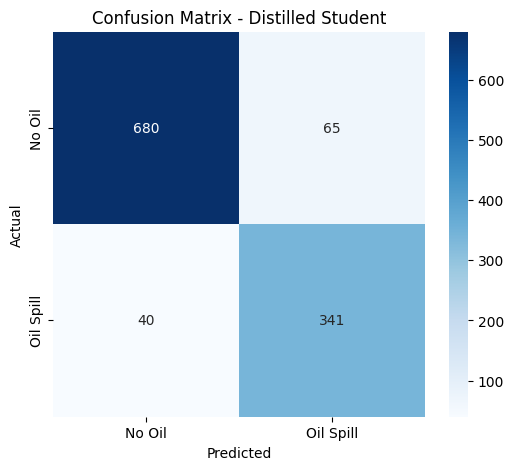

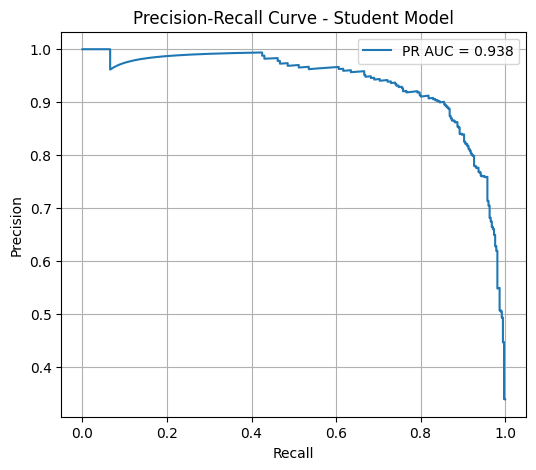

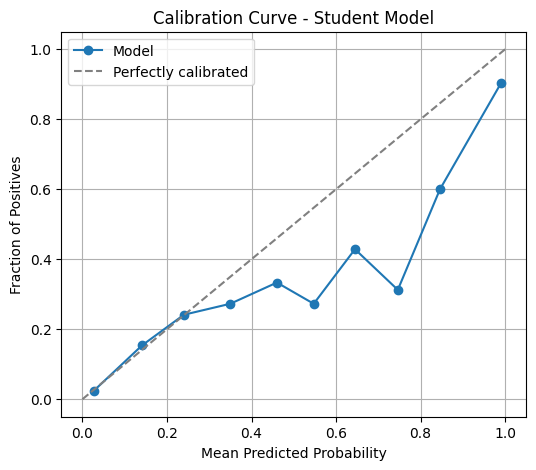

Expected Calibration Error (ECE): 0.1478


In [25]:
# Confusion matrix for student
y_true_stu, y_pred_stu = evaluate_model(student, test_loader, "Student")
cm = confusion_matrix(y_true_stu, y_pred_stu)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Oil', 'Oil Spill'], yticklabels=['No Oil', 'Oil Spill'])
plt.title('Confusion Matrix - Distilled Student')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# PR Curve
from sklearn.metrics import precision_recall_curve, auc
y_probs = []
student.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        probs = torch.softmax(student(x), dim=1)[:, 1]
        y_probs.extend(probs.cpu().numpy())
precision_vals, recall_vals, _ = precision_recall_curve(y_true_stu, y_probs)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Student Model')
plt.legend()
plt.grid(True)
plt.show()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true_stu, y_probs, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve - Student Model')
plt.legend()
plt.grid(True)
plt.show()
ece = np.mean(np.abs(prob_true - prob_pred))
print(f"Expected Calibration Error (ECE): {ece:.4f}")